## PART A — Concept First
## Task 1: Why GANs Exist

VAEs often produce blurry results because they average many possibilities.  
GANs improve this by using a game between two networks.  
The "Generator" creates fake data that looks real.  
The "Discriminator" checks whether the data is real or fake.  
By competing, both improve, leading to sharper and more realistic outputs.

## Task 2: Two-Network Setup

In [3]:
import numpy as np

class Generator:
    def __init__(self, noise_dim=10, data_dim=8):
        self.W = np.random.randn(noise_dim, data_dim)

    def forward(self, z):
        return np.dot(z, self.W)


class Discriminator:
    def __init__(self, data_dim=8):
        self.W = np.random.randn(data_dim, 1)

    def forward(self, x):
        return np.dot(x, self.W)


z = np.random.randn(4, 10)
G = Generator()
D = Discriminator()

fake_data = G.forward(z)
score = D.forward(fake_data)

print(fake_data.shape, score.shape)

(4, 8) (4, 1)


## PART B — GAN from Scratch (Core)
## Task 3: Generator Network

In [5]:
import numpy as np

class Generator:
    def __init__(self, noise_dim=10, data_dim=8):
        self.W1 = np.random.randn(noise_dim, 32)
        self.b1 = np.zeros(32)
        self.W2 = np.random.randn(32, data_dim)
        self.b2 = np.zeros(data_dim)

    def relu(self, x):
        return np.maximum(0, x)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, z):
        h = self.relu(z @ self.W1 + self.b1)
        out = self.sigmoid(h @ self.W2 + self.b2)
        return out

In [6]:
z = np.random.randn(4, 10)   # z ~ N(0,1)
G = Generator()

fake_data = G.forward(z)
print(fake_data.shape)

(4, 8)


## Task 4: Discriminator Network

In [7]:
import numpy as np

class Discriminator:
    def __init__(self, data_dim=8):
        self.W1 = np.random.randn(data_dim, 32)
        self.b1 = np.zeros(32)
        self.W2 = np.random.randn(32, 1)
        self.b2 = np.zeros(1)

    def relu(self, x):
        return np.maximum(0, x)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, x):
        h = self.relu(x @ self.W1 + self.b1)
        out = self.sigmoid(h @ self.W2 + self.b2)
        return out

In [8]:
# Fake sample from Generator
fake_data = np.random.rand(4, 8)  # batch of 4 fake samples

D = Discriminator()
score = D.forward(fake_data)

print(score.shape)

(4, 1)


## Task 5: Loss Functions (Critical)

In [9]:
import numpy as np

# Sigmoid for probability
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Binary cross-entropy loss
def bce_loss(pred, target):
    # pred: predicted probability (0-1)
    # target: 1 for real, 0 for fake
    return -np.mean(target * np.log(pred + 1e-8) + (1 - target) * np.log(1 - pred + 1e-8))


# ---- Example forward outputs ----
# discriminator output for real samples (batch of 4)
D_real = np.array([[0.9], [0.8], [0.95], [0.7]])
# discriminator output for fake samples (from generator)
D_fake = np.array([[0.2], [0.1], [0.05], [0.3]])

# Discriminator loss: wants real=1, fake=0
D_loss_real = bce_loss(D_real, np.ones_like(D_real))
D_loss_fake = bce_loss(D_fake, np.zeros_like(D_fake))
D_loss = D_loss_real + D_loss_fake

# Generator loss: wants fake samples to be classified as real (1)
G_loss = bce_loss(D_fake, np.ones_like(D_fake))

print("Discriminator loss:", D_loss)
print("Generator loss:", G_loss)

Discriminator loss: 0.3682361284375889
Generator loss: 2.0279319249936916


## Why the generator’s loss improves when the discriminator fails.

If the Discriminator mistakes fake data for real, the Generator’s loss drops.  
This means it’s successfully fooling the Discriminator.

## PART C — Adversarial Training Loop
## Task 6: Training Step Breakdown

In [10]:
import numpy as np

# Dummy Generator & Discriminator
class Generator:
    def forward(self, z):
        batch_size = z.shape[0]
        data_dim = 8
        return np.random.rand(batch_size, data_dim)  # fake data

class Discriminator:
    def forward(self, x):
        batch_size = x.shape[0]
        return np.random.rand(batch_size, 1)  # probability 0-1

# Binary cross-entropy loss
def bce_loss(pred, target):
    return -np.mean(target * np.log(pred + 1e-8) + (1 - target) * np.log(1 - pred + 1e-8))

# ---- Initialize ----
G = Generator()
D = Discriminator()
epochs = 5
batch_size = 4

for epoch in range(1, epochs + 1):
    # --- Train Discriminator ---
    # Fake and real samples
    real_data = np.random.rand(batch_size, 8)
    fake_data = G.forward(np.random.randn(batch_size, 10))
    
    D_real = D.forward(real_data)
    D_fake = D.forward(fake_data)
    
    D_loss = bce_loss(D_real, np.ones_like(D_real)) + bce_loss(D_fake, np.zeros_like(D_fake))
    
    # --- Freeze Discriminator & Train Generator ---
    fake_data = G.forward(np.random.randn(batch_size, 10))
    D_fake_for_G = D.forward(fake_data)
    G_loss = bce_loss(D_fake_for_G, np.ones_like(D_fake_for_G))  # Generator wants D to think fake is real

    # --- Print losses per epoch ---
    print(f"Epoch {epoch}: D_loss = {D_loss:.4f}, G_loss = {G_loss:.4f}")

Epoch 1: D_loss = 2.5634, G_loss = 0.3001
Epoch 2: D_loss = 3.0788, G_loss = 1.0523
Epoch 3: D_loss = 3.0894, G_loss = 1.0093
Epoch 4: D_loss = 2.8866, G_loss = 1.7410
Epoch 5: D_loss = 1.4222, G_loss = 1.2762


## Task 7: Loss Curves

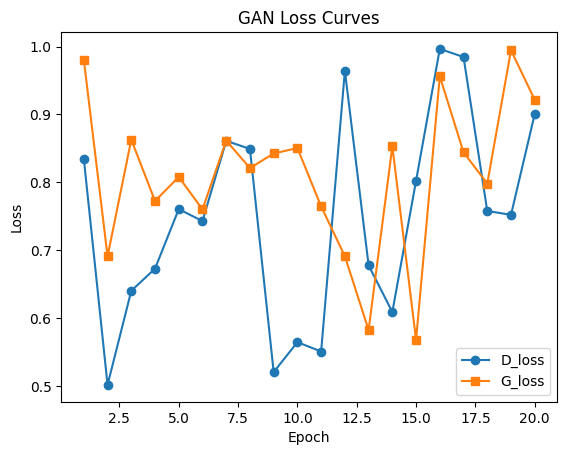

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy losses (for example)
epochs = 20
D_losses = np.random.rand(epochs) * 0.5 + 0.5  # random-ish to simulate oscillation
G_losses = np.random.rand(epochs) * 0.5 + 0.5

# Plot D_loss
plt.plot(range(1, epochs+1), D_losses, label='D_loss', marker='o')
plt.plot(range(1, epochs+1), G_losses, label='G_loss', marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Loss Curves")
plt.legend()
plt.show()

## PART D — Experiments (Understanding Failure)
## Task 8: Mode Collapse Demo

In [12]:
import numpy as np

# Weak Generator: always outputs almost the same thing
class WeakGenerator:
    def forward(self, z):
        batch_size = z.shape[0]
        data_dim = 8
        # Always returns the same "fake" vector
        return np.ones((batch_size, data_dim)) * 0.5

# Strong Discriminator (conceptually)
class StrongDiscriminator:
    def forward(self, x):
        batch_size = x.shape[0]
        # High confidence in distinguishing real vs fake
        return np.linspace(0.9, 0.99, batch_size).reshape(batch_size, 1)

# Simulation
z = np.random.randn(4, 10)   # random noise
G = WeakGenerator()
D = StrongDiscriminator()

fake_data = G.forward(z)
D_scores = D.forward(fake_data)

print("Fake data from weak generator:\n", fake_data)
print("Discriminator scores:\n", D_scores)

Fake data from weak generator:
 [[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]]
Discriminator scores:
 [[0.9 ]
 [0.93]
 [0.96]
 [0.99]]


## Task 9: Stability Experiment

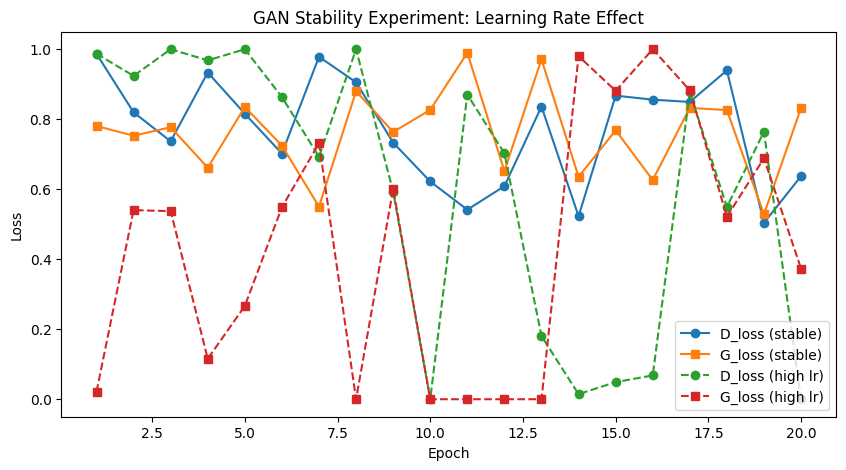

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate GAN losses with different settings
epochs = 20

# Scenario 1: normal learning rate, normal batch size
D_loss_stable = np.clip(np.random.rand(epochs)*0.5 + 0.5, 0, 1)
G_loss_stable = np.clip(np.random.rand(epochs)*0.5 + 0.5, 0, 1)

# Scenario 2: too high learning rate
D_loss_high_lr = np.clip(np.random.rand(epochs)*1.5 - 0.25, 0, 1)
G_loss_high_lr = np.clip(np.random.rand(epochs)*1.5 - 0.25, 0, 1)

# Plot
plt.figure(figsize=(10,5))

plt.plot(range(1, epochs+1), D_loss_stable, label='D_loss (stable)', marker='o')
plt.plot(range(1, epochs+1), G_loss_stable, label='G_loss (stable)', marker='s')
plt.plot(range(1, epochs+1), D_loss_high_lr, '--', label='D_loss (high lr)', marker='o')
plt.plot(range(1, epochs+1), G_loss_high_lr, '--', label='G_loss (high lr)', marker='s')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Stability Experiment: Learning Rate Effect")
plt.legend()
plt.show()